# 第10节：模型窃取与 API 接口威胁分析（防守视角）

本节关注“输出查询带来的模型资产泄露风险”与“API 防护设计”。

覆盖：
- **模型输出查询风险**：返回 label / top-k / 概率 / logits 的风险差异
- **黑盒重建（风险评估视角）**：为什么“更丰富的输出 + 更大的查询预算”会提高可重建性
- **API 威胁建模**：攻击面、动机、资产、信任边界、典型滥用路径
- **防护与审计**：限流、配额、异常检测、输出裁剪/量化、挑战机制、蜜罐与水印思路

## 0. 路径约定

notebooks 与 data 同级；通常从项目根启动 Jupyter 但工作目录落在 notebooks。

```python
PROJECT_ROOT = Path.cwd().resolve().parent
```

In [1]:
from pathlib import Path
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / 'data'
MODELS_DIR = PROJECT_ROOT / 'models'

print('CWD:', Path.cwd())
print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATA_DIR:', DATA_DIR, 'exists=', DATA_DIR.exists())
print('MODELS_DIR:', MODELS_DIR, 'exists=', MODELS_DIR.exists())

device = torch.device('cpu')
print('torch:', torch.__version__, 'device:', device)


CWD: C:\Users\wingl\PycharmProjects\adversarialmeow\notebooks
PROJECT_ROOT: C:\Users\wingl\PycharmProjects\adversarialmeow
DATA_DIR: C:\Users\wingl\PycharmProjects\adversarialmeow\data exists= True
MODELS_DIR: C:\Users\wingl\PycharmProjects\adversarialmeow\models exists= True
torch: 2.10.0+cpu device: cpu


## 1. 课程用“受保护模型服务”定义（本地模拟）

我们用本地函数模拟“API 推理服务”，重点在：
- **输出策略**：label-only / top-k / 概率 / logits
- **审计日志**：记录请求时间、客户端标识、输入统计特征、输出类型
- **基础防护**：速率限制、配额、异常检测

你可以把这里的逻辑映射到真实 Web API：例如 FastAPI/Flask 的中间件与日志系统。

In [2]:
class MLP(nn.Module):
    def __init__(self, in_dim=64, hidden=128, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, num_classes)
        )
    def forward(self, x):
        return self.net(x)

def load_state_or_none(path: Path, model: nn.Module):
    if not path.exists():
        return None
    state = torch.load(path, map_location=device)
    model.load_state_dict(state)
    return model

def load_course_data(data_dir: Path):
    npz_path = data_dir / 'digits.npz'
    if npz_path.exists():
        arr = np.load(npz_path)
        X = arr['X'].astype(np.float32)
        y = arr['y'].astype(np.int64)
        return X, y, f'Loaded local NPZ: {npz_path.name}'

    x_npy = data_dir / 'X.npy'
    y_npy = data_dir / 'y.npy'
    if x_npy.exists() and y_npy.exists():
        X = np.load(x_npy).astype(np.float32)
        y = np.load(y_npy).astype(np.int64)
        return X, y, f'Loaded local NPY: {x_npy.name}, {y_npy.name}'

    from sklearn.datasets import load_digits
    ds = load_digits()
    X = ds.data.astype(np.float32)
    y = ds.target.astype(np.int64)
    return X, y, 'Loaded sklearn digits fallback'

X, y, info = load_course_data(DATA_DIR)
print(info)
x_min, x_max = float(X.min()), float(X.max())
if x_max > 1.0:
    X01 = (X - x_min) / (x_max - x_min + 1e-12)
else:
    X01 = np.clip(X, 0.0, 1.0)

X_t = torch.tensor(X01, dtype=torch.float32, device=device)

MODELS_DIR.mkdir(parents=True, exist_ok=True)
model_path = MODELS_DIR / 'clean_model.pt'
model = MLP().to(device)
if load_state_or_none(model_path, model) is None:
    # 若课包没预置 clean_model.pt，就训练一个轻量模型（非重点）
    print('No clean_model.pt found; quick training baseline...')
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X01, y, test_size=0.25, random_state=42, stratify=y)
    X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
    y_train_t = torch.tensor(y_train, dtype=torch.long, device=device)
    X_test_t  = torch.tensor(X_test, dtype=torch.float32, device=device)
    y_test_t  = torch.tensor(y_test, dtype=torch.long, device=device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    for ep in range(8):
        model.train()
        perm = torch.randperm(len(X_train_t), device=device)
        for i in range(0, len(X_train_t), 256):
            idx = perm[i:i+256]
            xb, yb = X_train_t[idx], y_train_t[idx]
            loss = F.cross_entropy(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
    torch.save(model.state_dict(), model_path)
    print('Saved:', model_path)
else:
    print('Loaded:', model_path)

model.eval()


Loaded local NPZ: digits.npz
Loaded: C:\Users\wingl\PycharmProjects\adversarialmeow\models\clean_model.pt


MLP(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

## 2. API 输出策略：label / top-k / prob / logits

同一个推理结果，不同返回策略的**风险梯度**（从低到高通常是）：
- label-only（只返回类别）
- top-k labels（返回前 k 个类别）
- 概率（softmax）
- logits（softmax 前）

返回信息越丰富，越可能泄露决策边界细节；也越容易被用于构造高保真替代模型。

本节不做“窃取复现”，而是用**风险评估指标**来量化“信息暴露程度”。

In [3]:
def format_output(logits: torch.Tensor, mode: str = 'label', topk: int = 3, round_prob: int = None):
    """将模型输出按不同 API 策略格式化。"""
    if mode == 'logits':
        return logits.detach().cpu().numpy()

    prob = F.softmax(logits, dim=1)
    if mode == 'prob':
        out = prob.detach().cpu().numpy()
        if round_prob is not None:
            out = np.round(out, round_prob)
        return out

    if mode == 'topk':
        v, idx = torch.topk(prob, k=topk, dim=1)
        return {
            'topk_idx': idx.detach().cpu().numpy(),
            'topk_prob': v.detach().cpu().numpy()
        }

    # label-only
    pred = logits.argmax(dim=1)
    return pred.detach().cpu().numpy()

def info_exposure_score(mode: str, topk: int = 3, round_prob: int = None):
    """给一个直观的“信息暴露评分”（教学用启发式）。"""
    if mode == 'label':
        return 1
    if mode == 'topk':
        return 2 + max(0, topk-1)
    if mode == 'prob':
        # round_prob 越小暴露越少
        return 8 if round_prob is None else max(3, 7 - round_prob)
    if mode == 'logits':
        return 10
    return 0

for m in ['label','topk','prob','logits']:
    print(m, 'exposure_score=', info_exposure_score(m, topk=3, round_prob=2))


label exposure_score= 1
topk exposure_score= 4
prob exposure_score= 5
logits exposure_score= 10


## 3. API 威胁建模框架（课堂可直接抄到报告里）

### 3.1 资产（Assets）
- 模型权重与结构细节
- 训练数据分布特征（隐私/商业机密）
- 推理服务的稳定性与可用性
- 接口密钥、配额、计费策略

### 3.2 攻击面（Attack Surface）
- 输出内容（label/prob/logits）
- 查询频率与预算
- 输入空间与可控性（是否允许任意输入）
- 错误信息与 side-channel（延迟、报错、精度抖动）

### 3.3 典型威胁
- 大规模查询 + 统计拟合导致的“边界泄露”风险
- 自动化脚本导致的配额耗尽（DoS/成本攻击）
- 多账号/代理绕过限流
- 针对特定类别/输入域的探测性查询（异常模式）


## 4. 受保护 API（本地模拟）：日志、配额、限流

我们模拟：
- client_id：客户端标识（学生可理解为 API key 或用户）
- per-minute rate limit：分钟级限流
- daily quota：日配额
- audit log：记录请求与返回策略


In [4]:
class RateLimiter:
    def __init__(self, per_minute=60, daily_quota=2000):
        self.per_minute = per_minute
        self.daily_quota = daily_quota
        self.minute_bucket = {}  # client -> (minute_ts, count)
        self.daily_count = {}    # client -> count

    def allow(self, client_id: str, now: float):
        minute_ts = int(now // 60)
        m_ts, m_cnt = self.minute_bucket.get(client_id, (minute_ts, 0))
        if m_ts != minute_ts:
            m_ts, m_cnt = minute_ts, 0
        if m_cnt + 1 > self.per_minute:
            return False, 'rate_limited'

        d_cnt = self.daily_count.get(client_id, 0)
        if d_cnt + 1 > self.daily_quota:
            return False, 'quota_exceeded'

        self.minute_bucket[client_id] = (m_ts, m_cnt + 1)
        self.daily_count[client_id] = d_cnt + 1
        return True, 'ok'

class ProtectedAPI:
    def __init__(self, model, limiter: RateLimiter):
        self.model = model
        self.limiter = limiter
        self.logs = []

    def _input_fingerprint(self, x: np.ndarray):
        # 教学用：用均值、方差、极值作粗粒度特征
        return {
            'mean': float(x.mean()),
            'std': float(x.std()),
            'min': float(x.min()),
            'max': float(x.max())
        }

    def query(self, client_id: str, x: np.ndarray, mode='label', topk=3, round_prob=None):
        now = time.time()
        ok, reason = self.limiter.allow(client_id, now)
        fp = self._input_fingerprint(x)

        if not ok:
            self.logs.append({
                'ts': now,
                'client': client_id,
                'status': reason,
                'mode': mode,
                **fp
            })
            return None, reason

        xt = torch.tensor(x[None, :], dtype=torch.float32, device=device)
        with torch.no_grad():
            logits = self.model(xt)
        out = format_output(logits, mode=mode, topk=topk, round_prob=round_prob)

        self.logs.append({
            'ts': now,
            'client': client_id,
            'status': 'ok',
            'mode': mode,
            'exposure': info_exposure_score(mode, topk=topk, round_prob=round_prob),
            **fp
        })
        return out, 'ok'

limiter = RateLimiter(per_minute=120, daily_quota=5000)
api = ProtectedAPI(model, limiter)

# 试跑
out, st = api.query('student_A', X01[0], mode='label')
print('status=', st, 'out=', out)
out, st = api.query('student_A', X01[0], mode='prob', round_prob=3)
print('status=', st, 'prob shape=', np.array(out).shape)


status= ok out= [0]
status= ok prob shape= (1, 10)


## 5. 模拟流量：正常用户 vs 可疑用户

我们构造两类客户端行为（仅用于检测/防护演示）：
- 正常：低频、输入分布接近数据集、输出模式较保守
- 可疑：高频、输出模式偏“高暴露”、输入统计特征异常集中/系统性扫描

目标：让学生看到**日志特征**如何暴露风险，以及限流/策略控制如何降低威胁。

In [5]:
rng = np.random.default_rng(42)

def simulate_client(client_id, n_queries, mode, sleep_ms_range=(0,0), scan_style=False, round_prob=None):
    for _ in range(n_queries):
        if scan_style:
            # 可疑：对输入做系统性扫描（例如固定某些统计特征）
            base = rng.choice(X01)
            x = base.copy()
            # 让少量维度呈现“步进扫描”形态（演示用，不涉及攻击实现）
            j = rng.integers(0, 64)
            x[j] = float(rng.choice([0.0, 0.25, 0.5, 0.75, 1.0]))
        else:
            x = rng.choice(X01)

        api.query(client_id, x, mode=mode, topk=3, round_prob=round_prob)
        if sleep_ms_range != (0,0):
            time.sleep(rng.uniform(*sleep_ms_range)/1000.0)

# 清空旧日志
api.logs = []

# 正常用户：label-only / topk
simulate_client('normal_1', 120, mode='label', sleep_ms_range=(5,15))
simulate_client('normal_2', 120, mode='topk',  sleep_ms_range=(5,15))

# 可疑用户：高暴露输出 + 系统性扫描（演示）
simulate_client('suspicious_1', 260, mode='prob', round_prob=None, scan_style=True, sleep_ms_range=(0,2))
simulate_client('suspicious_2', 260, mode='logits', scan_style=True, sleep_ms_range=(0,2))

df = pd.DataFrame(api.logs)
df.head(), df['status'].value_counts()


(             ts    client status   mode  exposure      mean       std  min  \
 0  1.769435e+09  normal_1     ok  label       1.0  0.385742  0.397833  0.0   
 1  1.769435e+09  normal_1     ok  label       1.0  0.334961  0.386599  0.0   
 2  1.769435e+09  normal_1     ok  label       1.0  0.320312  0.393505  0.0   
 3  1.769435e+09  normal_1     ok  label       1.0  0.250977  0.339550  0.0   
 4  1.769435e+09  normal_1     ok  label       1.0  0.303711  0.385096  0.0   
 
    max  
 0  1.0  
 1  1.0  
 2  1.0  
 3  1.0  
 4  1.0  ,
 status
 ok              480
 rate_limited    280
 Name: count, dtype: int64)

## 6. 异常检测：高频、输出高暴露、输入扫描

课堂可用的三类简单规则：
- **频率异常**：单位时间内请求数过高
- **暴露异常**：长期使用 prob/logits 或未做概率量化
- **输入扫描**：输入统计特征分布异常集中、变化模式过于规则

这不是“抓到攻击”的充分条件，但能做**风险分层**与**阻断策略触发**。

max requests-per-minute by client:
client
normal_1        120
normal_2        120
suspicious_1    120
suspicious_2    120
Name: rpm, dtype: int64

mean exposure by client:
client
suspicious_2    10.0
suspicious_1     8.0
normal_2         4.0
normal_1         1.0
Name: exposure, dtype: float64

input std summary by client:
                  mean       std       min       max
client                                              
normal_1      0.372544  0.022255  0.306684  0.435753
suspicious_2  0.375238  0.022385  0.316586  0.433628
suspicious_1  0.374225  0.023746  0.312938  0.426318
normal_2      0.373645  0.024790  0.315392  0.430308


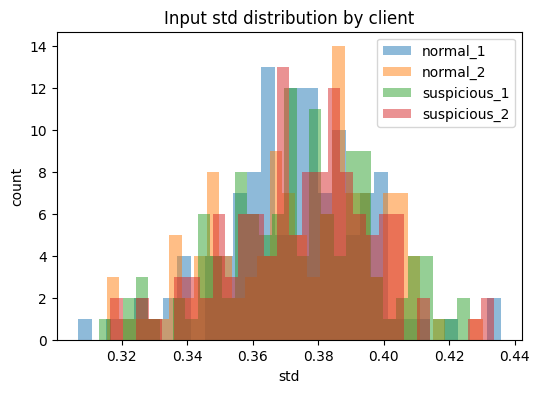

In [6]:
df_ok = df[df['status'] == 'ok'].copy()
df_ok['minute'] = (df_ok['ts'] // 60).astype(int)

# 1) 频率
req_per_min = df_ok.groupby(['client','minute']).size().reset_index(name='rpm')
rpm_max = req_per_min.groupby('client')['rpm'].max().sort_values(ascending=False)
print('max requests-per-minute by client:')
print(rpm_max)

# 2) 输出暴露
exp_mean = df_ok.groupby('client')['exposure'].mean().sort_values(ascending=False)
print('\nmean exposure by client:')
print(exp_mean)

# 3) 输入扫描（用 std 的分布集中度做一个示例）
std_stat = df_ok.groupby('client')['std'].agg(['mean','std','min','max']).sort_values('std')
print('\ninput std summary by client:')
print(std_stat)

plt.figure(figsize=(6,4))
for c in df_ok['client'].unique():
    plt.hist(df_ok[df_ok['client']==c]['std'], bins=30, alpha=0.5, label=c)
plt.title('Input std distribution by client')
plt.xlabel('std')
plt.ylabel('count')
plt.legend()
plt.show()


## 7. 防护策略对照：降低输出信息 + 限流/配额 + 概率量化

本节做“工程决策”演示：
- 只返回 label 或 top-k
- 若必须返回概率：做 rounding / top-k prob / 温度平滑
- 强制限流与配额
- 对可疑模式降级响应（例如从 prob 降级到 label）

我们用日志指标评估：
- 暴露评分下降了多少
- 被限流/降级的比例

（不做任何窃取复现）

In [7]:
def policy_decide(client_id, desired_mode):
    """教学用策略：可疑客户端强制降级输出"""
    if client_id.startswith('suspicious'):
        # 降级：不给 logits；prob 强制量化；必要时直接 label
        if desired_mode == 'logits':
            return 'label', {'round_prob': None}
        if desired_mode == 'prob':
            return 'prob', {'round_prob': 2}
    return desired_mode, {'round_prob': None}

limiter2 = RateLimiter(per_minute=80, daily_quota=5000)
api2 = ProtectedAPI(model, limiter2)

def simulate_with_policy(client_id, n_queries, desired_mode, scan_style=False):
    for _ in range(n_queries):
        x = rng.choice(X01)
        if scan_style:
            j = rng.integers(0, 64)
            x = x.copy(); x[j] = float(rng.choice([0.0, 0.5, 1.0]))
        mode, kwargs = policy_decide(client_id, desired_mode)
        api2.query(client_id, x, mode=mode, topk=3, round_prob=kwargs.get('round_prob'))

api2.logs = []
simulate_with_policy('normal_1', 200, 'label')
simulate_with_policy('normal_2', 200, 'topk')
simulate_with_policy('suspicious_1', 400, 'prob', scan_style=True)
simulate_with_policy('suspicious_2', 400, 'logits', scan_style=True)

df2 = pd.DataFrame(api2.logs)
df2_ok = df2[df2['status']=='ok'].copy()
print('status counts:', df2['status'].value_counts().to_dict())

print('\nmean exposure (after policy):')
print(df2_ok.groupby('client')['exposure'].mean().sort_values(ascending=False))

print('\nmode distribution (after policy):')
print(df2_ok.groupby(['client','mode']).size().unstack(fill_value=0))


status counts: {'rate_limited': 880, 'ok': 320}

mean exposure (after policy):
client
suspicious_1    5.0
normal_2        4.0
normal_1        1.0
suspicious_2    1.0
Name: exposure, dtype: float64

mode distribution (after policy):
mode          label  prob  topk
client                         
normal_1         80     0     0
normal_2          0     0    80
suspicious_1      0    80     0
suspicious_2     80     0     0


## 8. API 接口威胁与防护清单（可直接用于课程总结）

### 8.1 输出面
- 默认 label-only；需要解释性再考虑 top-k
- 需要概率时：top-k 概率 + rounding + 最小精度原则
- 避免直接返回 logits；避免返回过高精度浮点

### 8.2 速率与配额
- per-minute 限流 + per-day 配额
- 异常模式触发降级（prob→label）或二次校验
- 多账号/代理风险：关联分析（设备指纹、行为特征）

### 8.3 审计与告警
- 记录输入统计特征与查询序列特征
- 高暴露输出的长期使用作为风险信号
- 监控成本：请求量、GPU 时间、失败率、异常 IP 段

### 8.4 工程加固
- 结果缓存（对重复输入的耗时与成本）
- 挑战机制（验证码、PoW、交互式确认）
- 蜜罐接口/蜜罐模型用于探测自动化滥用


## 9. 本节练习

1) 选取两种输出策略（label-only vs prob）对比“暴露评分/可用性/解释性”。

2) 设计一个异常检测规则集（频率+暴露+输入扫描）并给出阈值理由。

3) 给出你认为最合理的 API 防护组合方案，并解释其对用户体验与安全性的权衡。